# Punto 1 · Notebook 00 – Descarga y filtrado de la estación MeteoNet

**Taller 1 – Aprendizaje Profundo** · Daniel Sebastian Velasco Munar

Este notebook se ejecuta **una sola vez** (idealmente en Google Colab). Hace tres cosas:

1. Descarga las observaciones de estaciones terrestres de MeteoNet para una zona (`NW` o `SE`) y los años 2016-2018 (~174 MB comprimidos por año).
2. Recorre los CSV por *chunks* y construye un **resumen de calidad por estación** (número de registros, % de valores faltantes por variable, cobertura temporal) → `results/punto1/resumen_estaciones_<zona>.csv`. Con esa tabla se justifica la selección de la estación.
3. Filtra la estación escogida, convierte unidades, remuestrea a frecuencia **horaria** y guarda `code/punto1_rnn_meteonet/data/estacion_<id>_horaria.csv` (archivo pequeño que sí se versiona en el repositorio). Los notebooks `01` y `02` parten de ese archivo.

Documentación de los datos: https://meteofrance.github.io/meteonet/english/data/ground-observations/

| Columna | Significado | Unidad original |
|---|---|---|
| `number_sta` | id de la estación | – |
| `lat`, `lon`, `height_sta` | ubicación y altitud | °, °, m |
| `date` | marca de tiempo (cada 6 min) | `YYYY-MM-DD HH:MM:SS` |
| `dd` | dirección del viento | ° |
| `ff` | velocidad del viento | m/s |
| `precip` | precipitación | kg/m² |
| `hu` | humedad relativa | % |
| `td` | punto de rocío | K |
| `t` | temperatura | K |
| `psl` | presión a nivel del mar | Pa |


## 0. Configuración

In [1]:
# --- Parámetros del notebook -------------------------------------------------
ZONA = "NW"                      # "NW" (noroeste) o "SE" (sureste) de Francia
ANIOS = [2016, 2017, 2018]

# Estación a extraer. Dejar en None la primera vez: el notebook construye el resumen
# de estaciones y se escoge con base en él. Luego se fija aquí el id elegido.
#ESTACION = None
ESTACION = 62548002

# Chunk para leer los CSV grandes sin agotar la RAM de Colab (~12 GB)
CHUNKSIZE = 2_000_000

# Rutas
USAR_DRIVE = False               # False: los crudos van al disco temporal de Colab (~100 GB libres).
                                 # True: se guardan en Drive; OJO, ocupan ~4.5 GB y pueden llenar la cuota gratuita.
RUTA_DRIVE_CACHE = "/content/drive/MyDrive/meteonet_raw"


In [2]:
import os, sys, tarfile, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm

EN_COLAB = "google.colab" in sys.modules
print("Ejecutando en Colab:", EN_COLAB)


Ejecutando en Colab: True


### 0.1 Repositorio y rutas de trabajo

En Colab se clona el repositorio para que las salidas queden en las carpetas correctas (`results/` y `code/punto1_rnn_meteonet/data/`) y se puedan hacer commit al final. En local se asume que el notebook se abre desde su carpeta dentro del repo.

In [3]:
REPO_URL = "https://github.com/DANIEL-VELASCO/taller1-deep-learning.git"   # <-- ajustar

if EN_COLAB:
    if not Path("/content/taller1-deep-learning").exists():
        !git clone {REPO_URL} /content/taller1-deep-learning
    RAIZ_REPO = Path("/content/taller1-deep-learning")
else:
    # notebook ubicado en code/punto1_rnn_meteonet/
    RAIZ_REPO = Path.cwd().resolve().parents[1]

RUTA_DATA = RAIZ_REPO / "code" / "punto1_rnn_meteonet" / "data"
RUTA_RESULTS = RAIZ_REPO / "results" / "punto1"
RUTA_DATA.mkdir(parents=True, exist_ok=True)
RUTA_RESULTS.mkdir(parents=True, exist_ok=True)

if EN_COLAB and USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    RUTA_RAW = Path(RUTA_DRIVE_CACHE)
else:
    RUTA_RAW = Path("/content/meteonet_raw") if EN_COLAB else RAIZ_REPO / "code" / "punto1_rnn_meteonet" / "raw"   # ignorada por git
RUTA_RAW.mkdir(parents=True, exist_ok=True)

print("Repo:     ", RAIZ_REPO)
print("Crudos:   ", RUTA_RAW)
print("Salida:   ", RUTA_DATA)


Cloning into '/content/taller1-deep-learning'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 43 (delta 12), reused 40 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 204.72 KiB | 5.53 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Repo:      /content/taller1-deep-learning
Crudos:    /content/meteonet_raw
Salida:    /content/taller1-deep-learning/code/punto1_rnn_meteonet/data


## 1. Descarga y extracción de los archivos crudos

In [4]:
BASE_URL = "https://meteonet.umr-cnrm.fr/dataset/data/{zona}/ground_stations/{zona}_ground_stations_{anio}.tar.gz"


def descargar(url: str, destino: Path, reintentos: int = 3) -> Path:
    """Descarga con barra de progreso; omite si el archivo ya existe."""
    if destino.exists() and destino.stat().st_size > 0:
        print(f"[ok] ya existe {destino.name} ({destino.stat().st_size/1e6:.0f} MB)")
        return destino
    for intento in range(1, reintentos + 1):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                total = int(r.headers.get("content-length", 0))
                tmp = destino.with_suffix(destino.suffix + ".part")
                with open(tmp, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=destino.name) as barra:
                    for bloque in r.iter_content(chunk_size=1 << 20):
                        f.write(bloque)
                        barra.update(len(bloque))
                tmp.rename(destino)
            return destino
        except Exception as e:
            print(f"  intento {intento} falló: {e}")
            time.sleep(5)
    raise RuntimeError(f"No se pudo descargar {url}")


def extraer_csv(tar_path: Path, carpeta: Path) -> Path:
    """Extrae el CSV del tar.gz (estructura: <ZONA><anio>.tar.gz -> <ZONA><anio>.csv). Omite si ya existe."""
    with tarfile.open(tar_path, "r:gz") as tar:
        miembros = [m for m in tar.getmembers() if m.name.lower().endswith(".csv")]
        assert miembros, f"El archivo {tar_path.name} no contiene CSV"
        m = miembros[0]
        destino = carpeta / Path(m.name).name
        if destino.exists():
            print(f"[ok] ya extraído {destino.name} ({destino.stat().st_size/1e9:.2f} GB)")
            return destino
        print(f"extrayendo {m.name} ...")
        m.name = Path(m.name).name      # aplanar rutas internas
        tar.extract(m, path=carpeta, filter="data")
    return destino


CSV_POR_ANIO = {}
for anio in ANIOS:
    url = BASE_URL.format(zona=ZONA, anio=anio)
    tgz = descargar(url, RUTA_RAW / f"{ZONA}_ground_stations_{anio}.tar.gz")
    CSV_POR_ANIO[anio] = extraer_csv(tgz, RUTA_RAW)

CSV_POR_ANIO


NW_ground_stations_2016.tar.gz:   0%|          | 0.00/181M [00:00<?, ?B/s]

extrayendo NW2016.csv ...


NW_ground_stations_2017.tar.gz:   0%|          | 0.00/183M [00:00<?, ?B/s]

extrayendo NW2017.csv ...


NW_ground_stations_2018.tar.gz:   0%|          | 0.00/183M [00:00<?, ?B/s]

extrayendo NW2018.csv ...


{2016: PosixPath('/content/meteonet_raw/NW2016.csv'),
 2017: PosixPath('/content/meteonet_raw/NW2017.csv'),
 2018: PosixPath('/content/meteonet_raw/NW2018.csv')}

In [5]:
# Vistazo rápido a la estructura del primer archivo
muestra = pd.read_csv(CSV_POR_ANIO[ANIOS[0]], nrows=5)
display(muestra)
print(muestra.dtypes)


,number_sta,lat,lon,height_sta,date,dd,ff,precip,hu,td,t,psl
0,14066001,49.33,-0.43,2.0,20160101 00:00,210.0,4.4,0.0,91.0,278.45,279.85,NaN
1,14126001,49.15,0.04,125.0,20160101 00:00,NaN,NaN,0.0,99.0,278.35,278.45,NaN
2,14137001,49.18,-0.46,67.0,20160101 00:00,220.0,0.6,0.0,92.0,276.45,277.65,102360.0
3,14216001,48.93,-0.15,155.0,20160101 00:00,220.0,1.9,0.0,95.0,278.25,278.95,NaN
4,14296001,48.80,-1.03,339.0,20160101 00:00,NaN,NaN,0.0,NaN,NaN,278.35,NaN


number_sta      int64
lat           float64
lon           float64
height_sta    float64
date           object
dd            float64
ff            float64
precip        float64
hu            float64
td            float64
t             float64
psl           float64
dtype: object


## 2. Resumen de calidad por estación

Se recorre cada CSV por *chunks* acumulando, por estación: número de registros, número de valores no nulos por variable, primera y última fecha, y metadatos (lat, lon, altura). Con eso se calcula el % de faltantes por variable y la **cobertura** (registros observados / registros esperados a 6 min en los 3 años ≈ 262 800).

Criterios sugeridos para escoger la estación (a justificar en el informe):

- Cobertura alta y presente en los **tres años** (serie larga y continua).
- Menor % de faltantes en `t` (variable objetivo) y en las covariables útiles (`hu`, `td`, `psl`, `ff`).
- Muchas estaciones **no reportan `psl`**; si se quiere usar presión como covariable hay que escogerla entre las que sí la tienen.


In [6]:
VARIABLES = ["dd", "ff", "precip", "hu", "td", "t", "psl"]
FORMATO_FECHA = "%Y%m%d %H:%M"      # así viene la columna date en los CSV (ej. 20160101 00:00)
COLUMNAS = ["number_sta", "lat", "lon", "height_sta", "date"] + VARIABLES

RUTA_RESUMEN = RUTA_RESULTS / f"resumen_estaciones_{ZONA}.csv"

if RUTA_RESUMEN.exists():
    resumen = pd.read_csv(RUTA_RESUMEN)
    print(f"[ok] resumen ya calculado: {RUTA_RESUMEN}")
else:
    acumulados = []
    for anio, ruta in CSV_POR_ANIO.items():
        t0 = time.time()
        for chunk in tqdm(pd.read_csv(ruta, usecols=COLUMNAS, chunksize=CHUNKSIZE, parse_dates=["date"], date_format=FORMATO_FECHA),
                          desc=f"{ZONA}{anio}"):
            g = chunk.groupby("number_sta")
            parcial = g.agg(n_registros=("date", "size"),
                            fecha_min=("date", "min"),
                            fecha_max=("date", "max"),
                            lat=("lat", "first"), lon=("lon", "first"), height_sta=("height_sta", "first"))
            for v in VARIABLES:
                parcial[f"nn_{v}"] = g[v].count()
            parcial["anio"] = anio
            acumulados.append(parcial.reset_index())
        print(f"  {anio}: {time.time()-t0:.0f} s")

    parciales = pd.concat(acumulados, ignore_index=True)

    # Consolidar por estación (sumas de conteos, min/max de fechas, años presentes)
    agg = {"n_registros": "sum", "fecha_min": "min", "fecha_max": "max",
           "lat": "first", "lon": "first", "height_sta": "first",
           "anio": pd.Series.nunique}
    agg.update({f"nn_{v}": "sum" for v in VARIABLES})
    resumen = parciales.groupby("number_sta").agg(agg).rename(columns={"anio": "n_anios"}).reset_index()

    registros_esperados = len(pd.date_range(f"{ANIOS[0]}-01-01 00:00", f"{ANIOS[-1]}-12-31 23:54", freq="6min"))
    resumen["cobertura"] = resumen["n_registros"] / registros_esperados
    for v in VARIABLES:
        resumen[f"pct_nan_{v}"] = 1 - resumen[f"nn_{v}"] / resumen["n_registros"]
    resumen = resumen.drop(columns=[f"nn_{v}" for v in VARIABLES])
    resumen = resumen.sort_values(["n_anios", "pct_nan_t", "cobertura"], ascending=[False, True, False])
    resumen.to_csv(RUTA_RESUMEN, index=False)
    print("guardado:", RUTA_RESUMEN)

print(f"{len(resumen)} estaciones en la zona {ZONA}")
resumen.head(20).style.format({"cobertura": "{:.1%}", **{f"pct_nan_{v}": "{:.1%}" for v in VARIABLES}})


NW2016: 0it [00:00, ?it/s]

  2016: 33 s


NW2017: 0it [00:00, ?it/s]

  2017: 32 s


NW2018: 0it [00:00, ?it/s]

  2018: 32 s
guardado: /content/taller1-deep-learning/results/punto1/resumen_estaciones_NW.csv
287 estaciones en la zona NW


,number_sta,n_registros,fecha_min,fecha_max,lat,lon,height_sta,n_anios,cobertura,pct_nan_dd,pct_nan_ff,pct_nan_precip,pct_nan_hu,pct_nan_td,pct_nan_t,pct_nan_psl
228,76208001,262849,2016-01-01 00:00:00,2018-12-31 23:54:00,49.510000,1.720000,104.000000,3,99.9%,100.0%,100.0%,0.0%,100.0%,100.0%,0.0%,100.0%
251,79320002,262823,2016-01-01 00:00:00,2018-12-31 23:54:00,46.460000,-0.460000,100.000000,3,99.9%,100.0%,100.0%,0.0%,100.0%,100.0%,0.0%,100.0%
273,86021002,262807,2016-01-01 00:00:00,2018-12-31 23:54:00,46.570000,0.050000,150.000000,3,99.9%,100.0%,100.0%,0.0%,100.0%,100.0%,0.0%,100.0%
275,86039001,262592,2016-01-01 00:00:00,2018-12-31 23:54:00,46.280000,0.190000,148.000000,3,99.8%,100.0%,100.0%,0.0%,100.0%,100.0%,0.0%,100.0%
215,62548002,262587,2016-01-01 00:00:00,2018-12-31 23:54:00,50.960000,1.960000,3.000000,3,99.8%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
38,28064002,262574,2016-01-01 00:00:00,2018-12-31 23:54:00,48.800000,1.490000,132.000000,3,99.8%,100.0%,100.0%,0.0%,100.0%,100.0%,0.0%,100.0%
8,14501002,262265,2016-01-01 00:00:00,2018-12-31 23:54:00,48.890000,-0.390000,185.000000,3,99.7%,100.0%,100.0%,0.0%,100.0%,100.0%,0.0%,100.0%
46,28214003,261762,2016-01-01 00:00:00,2018-12-31 23:54:00,48.480000,1.010000,200.000000,3,99.5%,100.0%,100.0%,0.0%,100.0%,100.0%,0.0%,100.0%
42,28190001,259716,2016-01-01 00:00:00,2018-12-31 23:54:00,48.081000,1.666000,132.000000,3,98.7%,100.0%,100.0%,0.0%,5.6%,5.6%,0.0%,100.0%
243,79079013,259620,2016-01-01 00:00:00,2018-12-31 23:54:00,46.929000,-0.758000,150.000000,3,98.7%,100.0%,100.0%,0.0%,100.0%,100.0%,0.0%,100.0%


In [7]:
# Candidatas: 3 años completos, cobertura alta, pocos faltantes en temperatura y con presión disponible
n_anios_total = len(ANIOS)
candidatas = resumen.query("n_anios == @n_anios_total and cobertura > 0.95 and pct_nan_t < 0.02 and pct_nan_psl < 0.05")
print(f"{len(candidatas)} estaciones cumplen los criterios")
candidatas.head(15).style.format({"cobertura": "{:.1%}", **{f"pct_nan_{v}": "{:.1%}" for v in VARIABLES}})


46 estaciones cumplen los criterios


,number_sta,n_registros,fecha_min,fecha_max,lat,lon,height_sta,n_anios,cobertura,pct_nan_dd,pct_nan_ff,pct_nan_precip,pct_nan_hu,pct_nan_td,pct_nan_t,pct_nan_psl
215,62548002,262587,2016-01-01 00:00:00,2018-12-31 23:54:00,50.960000,1.960000,3.000000,3,99.8%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
61,29120001,261837,2016-01-01 00:00:00,2018-12-31 23:54:00,48.280000,-4.440000,83.000000,3,99.5%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
106,36173002,262857,2016-01-01 00:00:00,2018-12-31 23:54:00,46.700000,1.250000,110.000000,3,99.9%,0.0%,0.0%,0.0%,0.5%,0.6%,0.0%,0.1%
136,41281001,262444,2016-01-01 00:00:00,2018-12-31 23:54:00,47.680000,1.210000,130.000000,3,99.8%,0.2%,0.1%,0.1%,0.2%,0.2%,0.0%,0.0%
216,62826001,261829,2016-01-01 00:00:00,2018-12-31 23:54:00,50.510000,1.620000,20.000000,3,99.5%,0.1%,0.1%,0.2%,0.4%,0.4%,0.0%,0.4%
140,44103001,261381,2016-01-01 00:00:00,2018-12-31 23:54:00,47.310000,-2.150000,4.000000,3,99.4%,0.2%,0.2%,0.2%,0.0%,0.0%,0.0%,0.0%
34,27347001,262705,2016-01-01 00:00:00,2018-12-31 23:54:00,49.030000,1.220000,138.000000,3,99.9%,0.9%,0.9%,0.0%,0.0%,0.0%,0.0%,0.0%
62,29151004,261073,2016-01-01 00:00:00,2018-12-31 23:54:00,48.600000,-3.810000,90.000000,3,99.3%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
63,29155005,257141,2016-01-01 00:00:00,2018-12-31 23:54:00,48.470000,-5.060000,68.000000,3,97.8%,0.1%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%
29,22372001,262195,2016-01-01 00:00:00,2018-12-31 23:54:00,48.530000,-2.850000,135.000000,3,99.7%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%


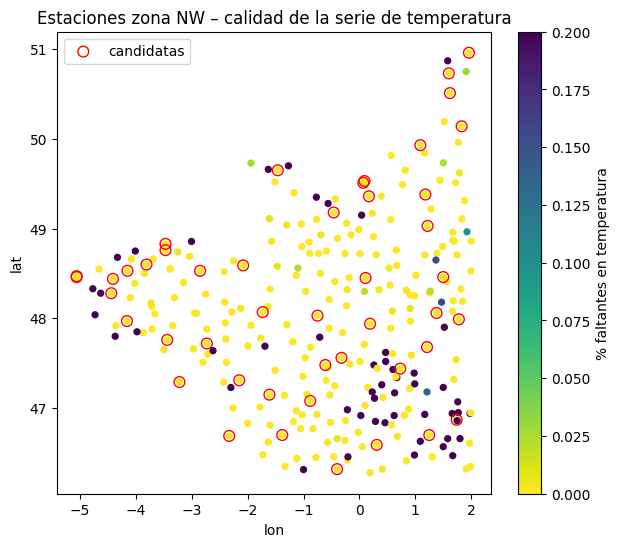

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(resumen["lon"], resumen["lat"], c=resumen["pct_nan_t"], cmap="viridis_r", s=18, vmin=0, vmax=0.2)
if len(candidatas):
    ax.scatter(candidatas["lon"], candidatas["lat"], facecolors="none", edgecolors="red", s=60, label="candidatas")
    ax.legend()
plt.colorbar(sc, label="% faltantes en temperatura")
ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.set_title(f"Estaciones zona {ZONA} – calidad de la serie de temperatura")
fig.savefig(RUTA_RESULTS / f"mapa_estaciones_{ZONA}.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Extracción de la estación escogida

Fijar `ESTACION` con el id elegido (o dejar `None` para tomar automáticamente la primera candidata). Se hace una segunda pasada por los CSV conservando solo las filas de esa estación.

In [9]:
if ESTACION is None:
    assert len(candidatas), "No hay candidatas con los criterios actuales; relajarlos o fijar ESTACION a mano."
    ESTACION = int(candidatas.iloc[0]["number_sta"])
print("Estación escogida:", ESTACION)
display(resumen.query("number_sta == @ESTACION").T)

partes = []
for anio, ruta in CSV_POR_ANIO.items():
    for chunk in tqdm(pd.read_csv(ruta, usecols=COLUMNAS, chunksize=CHUNKSIZE, parse_dates=["date"], date_format=FORMATO_FECHA),
                      desc=f"filtrando {ZONA}{anio}"):
        partes.append(chunk[chunk["number_sta"] == ESTACION])

serie_6min = (pd.concat(partes, ignore_index=True)
                .drop_duplicates(subset="date")
                .sort_values("date")
                .set_index("date"))
print(serie_6min.shape)
serie_6min.head()


Estación escogida: 62548002


,215
number_sta,62548002
n_registros,262587
fecha_min,2016-01-01 00:00:00
fecha_max,2018-12-31 23:54:00
lat,50.96
lon,1.96
height_sta,3.0
n_anios,3
cobertura,0.998278
pct_nan_dd,0.000263


filtrando NW2016: 0it [00:00, ?it/s]

filtrando NW2017: 0it [00:00, ?it/s]

filtrando NW2018: 0it [00:00, ?it/s]

(262587, 11)


,number_sta,lat,lon,height_sta,dd,ff,precip,hu,td,t,psl
date,,,,,,,,,,,
2016-01-01 00:00:00,62548002,50.96,1.96,3.0,220.0,3.9,0.0,87.0,277.95,279.95,102120.0
2016-01-01 00:06:00,62548002,50.96,1.96,3.0,220.0,3.6,0.0,87.0,277.75,279.75,102130.0
2016-01-01 00:12:00,62548002,50.96,1.96,3.0,230.0,3.2,0.0,86.0,277.25,279.45,102130.0
2016-01-01 00:18:00,62548002,50.96,1.96,3.0,240.0,3.3,0.0,85.0,277.45,279.75,102140.0
2016-01-01 00:24:00,62548002,50.96,1.96,3.0,240.0,3.4,0.0,82.0,276.85,279.75,102150.0


## 4. Conversión de unidades y remuestreo horario

- `t`, `td`: K → °C. `psl`: Pa → hPa.
- Remuestreo a 1 h: promedio para las variables de estado; **suma** para precipitación; la dirección del viento se promedia vectorialmente (`dd`, `ff` → componentes `u`, `v`).
- Se reindexa a una malla horaria completa para que las horas sin observación queden como `NaN` explícitos (la imputación se decide y documenta en el notebook `01`, sin usar información futura).


In [10]:
df = serie_6min.copy()
df["t_c"] = df["t"] - 273.15
df["td_c"] = df["td"] - 273.15
df["psl_hpa"] = df["psl"] / 100.0

# viento a componentes (convención meteorológica: dd es la dirección DESDE la que sopla)
rad = np.deg2rad(df["dd"])
df["u"] = -df["ff"] * np.sin(rad)
df["v"] = -df["ff"] * np.cos(rad)

horaria = pd.DataFrame({
    "t_c":      df["t_c"].resample("1h").mean(),
    "td_c":     df["td_c"].resample("1h").mean(),
    "hu":       df["hu"].resample("1h").mean(),
    "psl_hpa":  df["psl_hpa"].resample("1h").mean(),
    "ff":       df["ff"].resample("1h").mean(),
    "u":        df["u"].resample("1h").mean(),
    "v":        df["v"].resample("1h").mean(),
    "precip":   df["precip"].resample("1h").sum(min_count=1),
    "n_obs":    df["t"].resample("1h").count(),   # cuántas de las 10 observaciones posibles hubo
})

indice_completo = pd.date_range(f"{ANIOS[0]}-01-01 00:00", f"{ANIOS[-1]}-12-31 23:00", freq="1h")
horaria = horaria.reindex(indice_completo)
horaria.index.name = "date"

print(horaria.shape)
print("faltantes por columna:")
print(horaria.isna().mean().round(4))
horaria.describe().T


(26304, 9)
faltantes por columna:
t_c        0.0009
td_c       0.0009
hu         0.0009
psl_hpa    0.0009
ff         0.0010
u          0.0010
v          0.0010
precip     0.0010
n_obs      0.0000
dtype: float64


,count,mean,std,min,25%,50%,75%,max
t_c,26280.0,11.448059,5.995517,-7.630000,7.110000,11.235000,15.960000,33.260000
td_c,26280.0,8.047407,5.388293,-15.080000,4.190000,8.400000,12.400000,20.210000
hu,26280.0,80.901926,12.805951,24.600000,72.700000,83.400000,91.100000,100.000000
psl_hpa,26280.0,1016.349646,9.856703,971.560000,1010.887500,1017.380000,1022.940000,1046.110000
ff,26279.0,4.830119,2.873282,0.000000,2.590000,4.330000,6.690000,20.400000
u,26279.0,1.451065,4.001845,-13.682968,-1.324274,1.083714,4.193603,17.130097
v,26279.0,0.514608,3.586212,-15.538110,-1.820863,0.993268,2.887628,15.627307
precip,26278.0,0.080897,0.479216,0.000000,0.000000,0.000000,0.000000,21.900000
n_obs,26304.0,9.982778,0.354698,0.000000,10.000000,10.000000,10.000000,10.000000


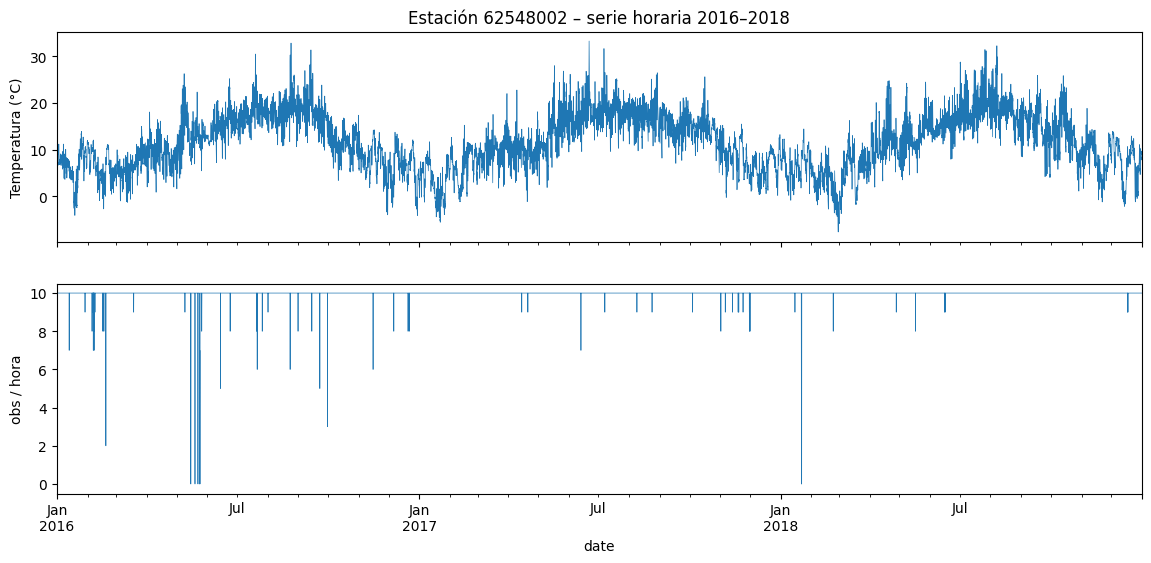

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
horaria["t_c"].plot(ax=axes[0], lw=0.5); axes[0].set_ylabel("Temperatura (°C)")
horaria["n_obs"].plot(ax=axes[1], lw=0.5); axes[1].set_ylabel("obs / hora")
axes[0].set_title(f"Estación {ESTACION} – serie horaria {ANIOS[0]}–{ANIOS[-1]}")
fig.savefig(RUTA_RESULTS / f"serie_horaria_estacion_{ESTACION}.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Guardar el archivo que usan los siguientes notebooks

In [12]:
RUTA_SALIDA = RUTA_DATA / f"estacion_{ESTACION}_horaria.csv"
horaria.round(3).to_csv(RUTA_SALIDA)

meta = resumen.query("number_sta == @ESTACION").iloc[0]
metadatos = {
    "zona": ZONA, "estacion": ESTACION, "anios": ANIOS,
    "lat": float(meta["lat"]), "lon": float(meta["lon"]), "height_sta": float(meta["height_sta"]),
    "frecuencia": "1h", "n_filas": int(len(horaria)),
    "pct_nan_t_c": float(horaria["t_c"].isna().mean()),
    "columnas": list(horaria.columns),
}
with open(RUTA_DATA / f"estacion_{ESTACION}_metadatos.json", "w") as f:
    json.dump(metadatos, f, indent=2)

print(f"guardado {RUTA_SALIDA} ({RUTA_SALIDA.stat().st_size/1e6:.2f} MB)")
metadatos


guardado /content/taller1-deep-learning/code/punto1_rnn_meteonet/data/estacion_62548002_horaria.csv (1.79 MB)


{'zona': 'NW',
 'estacion': 62548002,
 'anios': [2016, 2017, 2018],
 'lat': 50.96,
 'lon': 1.96,
 'height_sta': 3.0,
 'frecuencia': '1h',
 'n_filas': 26304,
 'pct_nan_t_c': 0.0009124087591240876,
 'columnas': ['t_c',
  'td_c',
  'hu',
  'psl_hpa',
  'ff',
  'u',
  'v',
  'precip',
  'n_obs']}

## 6. Guardar los resultados en el repositorio (solo en Colab)

Los archivos crudos quedan en Drive (cache) y están ignorados por git. Solo se versionan el CSV horario, los metadatos, el resumen de estaciones y las figuras.

In [13]:
if EN_COLAB:
    %cd {RAIZ_REPO}
    !git config user.name  "Daniel Sebastian Velasco Munar"
    !git config user.email "ds.velasco2170@gmail.com"
    !git status --short
    # Descomentar para hacer commit y push (requiere token de GitHub configurado en la URL o en git credential)
    # !git add results/punto1 code/punto1_rnn_meteonet/data
    # !git commit -m "Punto 1: resumen de estaciones y serie horaria de la estación {ESTACION}"
    # !git push


/content/taller1-deep-learning
?? code/punto1_rnn_meteonet/data/estacion_62548002_horaria.csv
?? code/punto1_rnn_meteonet/data/estacion_62548002_metadatos.json
?? results/punto1/mapa_estaciones_NW.png
?? results/punto1/resumen_estaciones_NW.csv
?? results/punto1/serie_horaria_estacion_62548002.png
